# 04 — Feature engineering

**Input:** `data/processed/interactions_clean.parquet` (474,011 rows)
**Output:** `data/processed/features.parquet` and `models/error_clusters.joblib`

### State features

| Feature | Meaning |
|---|---|
| `accuracy` | rolling first-attempt accuracy |
| `response_time` | normalised response time |
| `hint_rate` | help-seeking on incorrect attempts (see 4.3) |
| `error_cluster` | k-means cluster of recent error patterns, ordered by severity |

Four features, but seven columns, because `error_cluster` is one-hot encoded.

### Two rules

- **Backward-looking only:** each rolling feature uses interactions *before* the current one. Including the current row would leak the answer.
- **Per (student, skill):** accuracy on one skill says little about another.

In [1]:
import sys
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

EATS = Path(r"C:\Users\vedac\Desktop\EATS")
sys.path.insert(0, str(EATS))
PROCESSED = EATS / "data" / "processed"
FIGURES = EATS / "results" / "figures"
MODELS = EATS / "models"
MODELS.mkdir(parents=True, exist_ok=True)

pd.set_option("display.width", 170)
plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 300, "font.size": 9,
                     "axes.grid": True, "grid.alpha": 0.25})
BLUE, RED, GREY = "#4C72B0", "#C44E52", "#7F7F7F"

# --- design parameters ---------------------------
WINDOW = 10                 # rolling window, in interactions
CLIP_PERCENTILE = 99.0      # response-time outlier clip
N_CLUSTERS = 4              # proposal used k=4; checked in 4.6
SEED = 42

df = pd.read_parquet(PROCESSED / "interactions_clean.parquet")
df = df.sort_values(["user_id", "skill", "opportunity"]).reset_index(drop=True)
GROUP = ["user_id", "skill"]

print(f"{len(df):,} rows | {df['user_id'].nunique():,} students | {df['skill'].nunique()} skills")

474,011 rows | 12,119 students | 5 skills


## 4.1 Quiz accuracy

Rolling proportion correct over the last 10 interactions. A shorter window reacts faster but is noisy; a longer one is stable but slow. `shift(1)` keeps it backward-looking, and the first interaction of a sequence gets 0.5 (no history yet).

In [2]:
g = df.groupby(GROUP, observed=True)

df["accuracy"] = g["correct"].transform(
    lambda s: s.shift(1).rolling(WINDOW, min_periods=1).mean()
).fillna(0.5)

print(df["accuracy"].describe().round(3).to_string())

count    474011.000
mean          0.638
std           0.276
min           0.000
25%           0.500
50%           0.700
75%           0.857
max           1.000


## 4.2 Response time

1. Clip at the 99th percentile per skill. The maximum was 267 times the median (about 2.8 hours), most likely a tab left open.
2. Log transform, because the times are heavily skewed.
3. Normalise within skill and scale to [0, 1], so the feature doesn't just reflect which skill it is.

In [3]:
# Clip per SKILL, not per student: the outliers are a property of the problem
# format, and per-student clipping would need far more data per group.
clipped = df.groupby("skill", observed=True)["ms_first_response"].transform(
    lambda s: s.clip(upper=np.percentile(s, CLIP_PERCENTILE))
)

logged = np.log1p(clipped / 1000)  # seconds


def _z(s):
    sd = s.std()
    return (s - s.mean()) / sd if sd > 0 else s * 0.0


z = logged.groupby(df["skill"], observed=True).transform(_z)
df["response_time"] = (z.clip(-3, 3) + 3) / 6

print(df["response_time"].describe().round(3).to_string())
print(f"\nclipped {(df['ms_first_response'] > clipped).sum():,} values "
      f"({(df['ms_first_response'] > clipped).mean():.2%}) at the "
      f"{CLIP_PERCENTILE:.0f}th percentile")

count    474011.000
mean          0.500
std           0.167
min           0.000
25%           0.387
50%           0.500
75%           0.611
max           0.929

clipped 4,742 values (1.00%) at the 99th percentile


## 4.3 Hint rate — redefined

In this data no correct answer has a hint, because requesting a hint marks the item incorrect. So "hints per attempt" partly repeats the error rate.

Instead I use: of the incorrect attempts in the window, the proportion where the student asked for a hint. If the window has no incorrect attempts, the value is 0.

Both versions are computed below so they can be compared.

In [4]:
df["is_error"] = (1 - df["correct"]).astype(float)
df["used_hint"] = (df["hint_count"] > 0).astype(float)
df["hint_on_error"] = df["is_error"] * df["used_hint"]

g = df.groupby(GROUP, observed=True)

# Naive: hints per attempt (the definition the proposal implies)
df["hint_rate_naive"] = g["used_hint"].transform(
    lambda s: s.shift(1).rolling(WINDOW, min_periods=1).mean()
).fillna(0.0)

# Conditional: hints per INCORRECT attempt
errors_in_window = g["is_error"].transform(
    lambda s: s.shift(1).rolling(WINDOW, min_periods=1).sum()
)
hints_in_window = g["hint_on_error"].transform(
    lambda s: s.shift(1).rolling(WINDOW, min_periods=1).sum()
)
df["hint_rate"] = (hints_in_window / errors_in_window.replace(0, np.nan)).fillna(0.0)

print(df[["hint_rate_naive", "hint_rate"]].describe().round(3).to_string())

       hint_rate_naive   hint_rate
count       474011.000  474011.000
mean             0.183       0.379
std              0.258       0.421
min              0.000       0.000
25%              0.000       0.000
50%              0.100       0.167
75%              0.300       0.833
max              1.000       1.000


### Is it less tied to accuracy?

Compare the correlation of each version with `accuracy`.

In [5]:
r_naive = df["accuracy"].corr(df["hint_rate_naive"])
r_cond = df["accuracy"].corr(df["hint_rate"])

print(f"corr(accuracy, hint_rate_naive)       : {r_naive:+.3f}")
print(f"corr(accuracy, hint_rate_conditional) : {r_cond:+.3f}")
print(f"\nreduction in |correlation|            : "
      f"{abs(r_naive) - abs(r_cond):+.3f}")
print("\nA large drop means the conditional definition is measuring help-seeking")
print("rather than re-measuring error rate.")

corr(accuracy, hint_rate_naive)       : -0.677
corr(accuracy, hint_rate_conditional) : -0.396

reduction in |correlation|            : +0.280

A large drop means the conditional definition is measuring help-seeking
rather than re-measuring error rate.


## 4.4 Leakage check

The first interaction of every (student, skill) sequence has no history, so it should show the fallback value and nothing computed from its own row.

In [6]:
first = df.groupby(GROUP, observed=True).first()

checks = {
    "accuracy == 0.5 at first interaction": bool((first["accuracy"] == 0.5).all()),
    "hint_rate == 0.0 at first interaction": bool((first["hint_rate"] == 0.0).all()),
    "hint_rate_naive == 0.0 at first": bool((first["hint_rate_naive"] == 0.0).all()),
}
for k, v in checks.items():
    print(f"  {'PASS' if v else 'FAIL'}  {k}")

for col in ["accuracy", "response_time", "hint_rate"]:
    ok = df[col].between(0, 1).all() and df[col].notna().all()
    print(f"  {'PASS' if ok else 'FAIL'}  {col} within [0,1] and non-null")

assert all(checks.values()), "LEAKAGE DETECTED - do not proceed"
print("\nNo leakage.")

  PASS  accuracy == 0.5 at first interaction
  PASS  hint_rate == 0.0 at first interaction
  PASS  hint_rate_naive == 0.0 at first
  PASS  accuracy within [0,1] and non-null
  PASS  response_time within [0,1] and non-null
  PASS  hint_rate within [0,1] and non-null

No leakage.


## 4.5 Error-pattern profile

The aim is to separate occasional mistakes from repeated ones. Error rate alone can't do that, so the profile also includes streak length, attempts and hints taken on wrong answers.

In notebook 03, `hint_count` and `attempt_count` were strongly correlated with correctness (−0.62 and −0.49), so a profile of rates alone would mostly repeat accuracy.

In [7]:
def _max_run(window):
    """Longest consecutive run of errors in the window."""
    best = run = 0
    for v in window:
        if v > 0.5:
            run += 1
            best = max(best, run)
        else:
            run = 0
    return float(best)


g = df.groupby(GROUP, observed=True)

df["err_rate"] = g["is_error"].transform(
    lambda s: s.shift(1).rolling(WINDOW, min_periods=1).mean()
).fillna(0.0)

df["err_streak"] = g["is_error"].transform(
    lambda s: s.shift(1).rolling(WINDOW, min_periods=1).apply(_max_run, raw=True)
).fillna(0.0) / WINDOW

df["mean_attempts"] = g["attempt_count"].transform(
    lambda s: s.shift(1).rolling(WINDOW, min_periods=1).mean()
).fillna(1.0)

# Mean number of hints taken on the problems that were answered wrongly - a
# depth-of-help signal, distinct from the binary rate used as a state feature.
df["hints_when_wrong"] = df["hint_count"] * df["is_error"]
df["hint_depth"] = g["hints_when_wrong"].transform(
    lambda s: s.shift(1).rolling(WINDOW, min_periods=1).mean()
).fillna(0.0)

PROFILE = ["err_rate", "err_streak", "mean_attempts", "hint_depth"]
print(df[PROFILE].describe().round(3).to_string())

         err_rate  err_streak  mean_attempts  hint_depth
count  474011.000  474011.000     474011.000  474011.000
mean        0.337       0.174          1.407       0.525
std         0.285       0.177          0.690       0.814
min         0.000       0.000          0.000       0.000
25%         0.100       0.100          1.000       0.000
50%         0.300       0.100          1.200       0.100
75%         0.500       0.200          1.500       0.800
max         1.000       1.000         29.000       7.000


## 4.6 Choosing k

The proposal used k = 4. I check it with inertia (look for the elbow) and the silhouette score (higher means better separated).

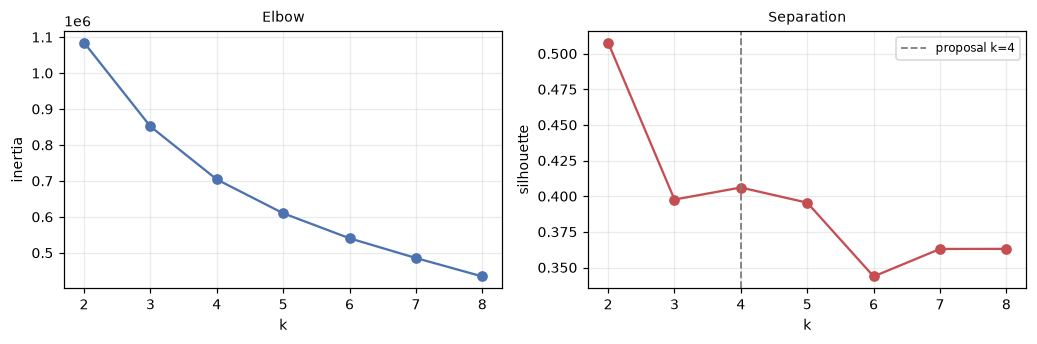

,k,inertia,silhouette
0,2,1.084887e+06,0.5078
1,3,8.515956e+05,0.3977
2,4,7.042205e+05,0.4061
3,5,6.101521e+05,0.3955
4,6,5.405552e+05,0.3437
5,7,4.856720e+05,0.3630
6,8,4.344217e+05,0.3631


In [8]:
scaler = StandardScaler()
X = scaler.fit_transform(df[PROFILE].to_numpy())

rng = np.random.default_rng(SEED)
sample = rng.choice(len(X), size=min(10_000, len(X)), replace=False)

rows = []
for k in range(2, 9):
    km = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    lab = km.fit_predict(X)
    rows.append({"k": k, "inertia": km.inertia_,
                 "silhouette": silhouette_score(X[sample], lab[sample])})
diag = pd.DataFrame(rows)

fig, (a1, a2) = plt.subplots(1, 2, figsize=(9.5, 3.2))
a1.plot(diag["k"], diag["inertia"], "o-", color=BLUE)
a1.set_xlabel("k"); a1.set_ylabel("inertia"); a1.set_title("Elbow", fontsize=9)
a2.plot(diag["k"], diag["silhouette"], "o-", color=RED)
a2.axvline(N_CLUSTERS, ls="--", c=GREY, lw=1.2, label=f"proposal k={N_CLUSTERS}")
a2.set_xlabel("k"); a2.set_ylabel("silhouette"); a2.set_title("Separation", fontsize=9)
a2.legend(fontsize=8)
fig.tight_layout()
fig.savefig(FIGURES / "fig_4_8_k_selection.png", bbox_inches="tight")
plt.show()

diag.round(4)

## 4.7 Fit and order clusters by severity

K-means labels are arbitrary, so I relabel the clusters by centroid error rate: 0 is the lowest and 3 the highest. The reward uses changes in cluster, so the order has to mean something.

In [9]:
km = KMeans(n_clusters=N_CLUSTERS, random_state=SEED, n_init=10)
raw_labels = km.fit_predict(X)

order = np.argsort(km.cluster_centers_[:, 0])       # column 0 is err_rate
remap = np.empty(N_CLUSTERS, dtype=int)
for new, old in enumerate(order):
    remap[old] = new
df["error_cluster"] = remap[raw_labels]

centroids = pd.DataFrame(
    scaler.inverse_transform(km.cluster_centers_[order]), columns=PROFILE
)
centroids.insert(0, "cluster", range(N_CLUSTERS))
centroids["share"] = [float((df["error_cluster"] == c).mean()) for c in range(N_CLUSTERS)]
centroids["accuracy_next"] = [
    float(df.loc[df["error_cluster"] == c, "correct"].mean()) for c in range(N_CLUSTERS)
]

assert centroids["err_rate"].is_monotonic_increasing, "clusters not severity-ordered"
print("severity ordering verified\n")
centroids.round(3)

severity ordering verified



,cluster,err_rate,err_streak,mean_attempts,hint_depth,share,accuracy_next
0,0,0.113,0.066,1.099,0.074,0.498,0.768
1,1,0.471,0.221,1.520,0.599,0.370,0.651
2,2,0.765,0.226,4.309,1.440,0.025,0.552
3,3,0.814,0.501,1.779,2.153,0.107,0.409


### Cluster names

Names used, based on the profiles: 0 on track, 1 occasional difficulty, 2 unproductive persistence, 3 systematic misconception.

`accuracy_next` should fall as the cluster number rises. If it didn't, the ordering wouldn't reflect anything real.

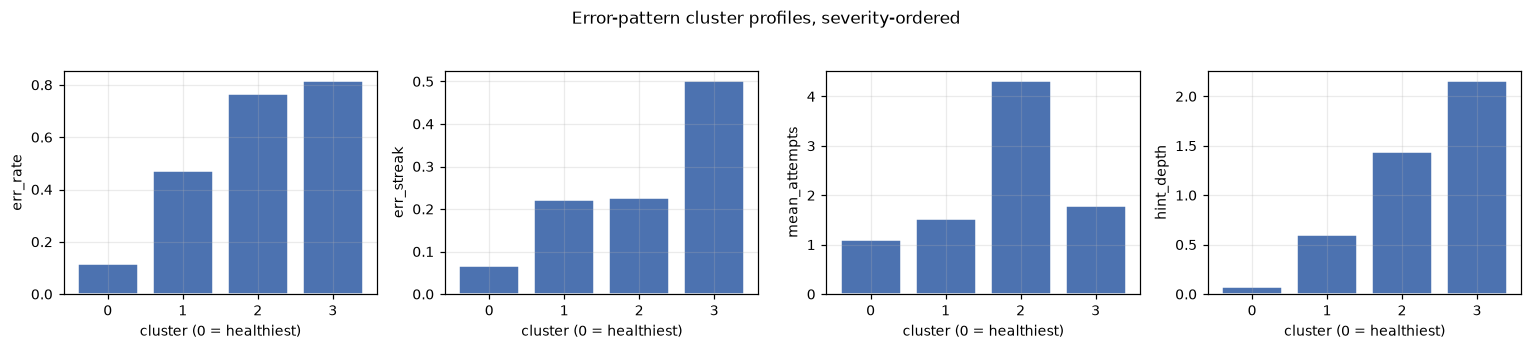

In [10]:
fig, axes = plt.subplots(1, 4, figsize=(14, 3.0))
for ax, col in zip(axes, PROFILE):
    ax.bar(centroids["cluster"], centroids[col], color=BLUE, edgecolor="white")
    ax.set_xlabel("cluster (0 = healthiest)")
    ax.set_ylabel(col)
    ax.set_xticks(range(N_CLUSTERS))
fig.suptitle("Error-pattern cluster profiles, severity-ordered", y=1.04)
fig.tight_layout()
fig.savefig(FIGURES / "fig_4_9_cluster_profiles.png", bbox_inches="tight")
plt.show()

centroids.to_csv(PROCESSED / "cluster_profiles.csv", index=False)

## 4.8 Assemble and save

Seven columns: three continuous and four one-hot. The cluster model and scaler are saved so the environment can assign clusters to simulated students.

In [11]:
onehot = pd.get_dummies(df["error_cluster"], prefix="cluster").astype(float)
for c in range(N_CLUSTERS):
    col = f"cluster_{c}"
    if col not in onehot:
        onehot[col] = 0.0
onehot = onehot[[f"cluster_{c}" for c in range(N_CLUSTERS)]]

STATE_COLS = ["accuracy", "response_time", "hint_rate"] + list(onehot.columns)
df = pd.concat([df, onehot], axis=1)

out_cols = (
    ["user_id", "skill", "opportunity", "correct", "start_time"]
    + STATE_COLS + PROFILE + ["error_cluster", "hint_rate_naive"]
)
features = df[out_cols].copy()
features.to_parquet(PROCESSED / "features.parquet", index=False)

joblib.dump({"kmeans": km, "scaler": scaler, "remap": remap,
             "profile_cols": PROFILE, "window": WINDOW,
             "clip_percentile": CLIP_PERCENTILE},
            MODELS / "error_clusters.joblib")

print(f"state dimension: {len(STATE_COLS)}  ({STATE_COLS})")
print(f"\nsaved features.parquet  ({len(features):,} rows)")
print(f"saved models/error_clusters.joblib")
features[STATE_COLS].describe().round(3)

state dimension: 7  (['accuracy', 'response_time', 'hint_rate', 'cluster_0', 'cluster_1', 'cluster_2', 'cluster_3'])

saved features.parquet  (474,011 rows)
saved models/error_clusters.joblib


,accuracy,response_time,hint_rate,cluster_0,cluster_1,cluster_2,cluster_3
count,474011.000,474011.000,474011.000,474011.000,474011.000,474011.000,474011.000
mean,0.638,0.500,0.379,0.498,0.370,0.025,0.107
std,0.276,0.167,0.421,0.500,0.483,0.155,0.309
min,0.000,0.000,0.000,0.000,0.000,0.000,0.000
25%,0.500,0.387,0.000,0.000,0.000,0.000,0.000
50%,0.700,0.500,0.167,0.000,0.000,0.000,0.000
75%,0.857,0.611,0.833,1.000,1.000,0.000,0.000
max,1.000,0.929,1.000,1.000,1.000,1.000,1.000


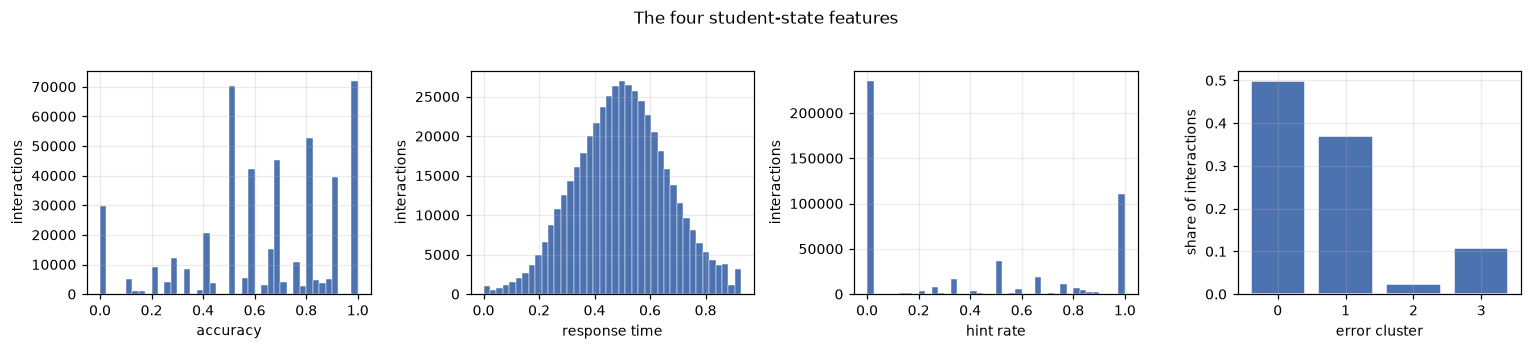

In [12]:
fig, axes = plt.subplots(1, 4, figsize=(14, 3.0))
for ax, col in zip(axes, ["accuracy", "response_time", "hint_rate"]):
    ax.hist(features[col], bins=40, color=BLUE, edgecolor="white", linewidth=0.3)
    ax.set_xlabel(col.replace("_", " ")); ax.set_ylabel("interactions")
axes[3].bar(range(N_CLUSTERS),
            [float((features["error_cluster"] == c).mean()) for c in range(N_CLUSTERS)],
            color=BLUE, edgecolor="white")
axes[3].set_xlabel("error cluster"); axes[3].set_ylabel("share of interactions")
axes[3].set_xticks(range(N_CLUSTERS))
fig.suptitle("The four student-state features", y=1.04)
fig.tight_layout()
fig.savefig(FIGURES / "fig_4_10_state_features.png", bbox_inches="tight")
plt.show()